# 03 — Explore embedding geometry

Semantic retrieval turns chunk text into vectors. Chunks with related meaning should lie closer together in the embedding space, even when they do not share many words. This notebook projects those high-dimensional vectors into two dimensions for exploration.

A 2D projection is an approximation, not a proof of semantic quality. Use it to generate questions and hypotheses; use the labelled retrieval benchmark to measure decisions.

## Preparation

This notebook needs Matplotlib. It is intentionally not a hidden notebook-only dependency. From the repository root, install it once before running this notebook:

```bash
uv add matplotlib
```

Then restart the Jupyter kernel if it was already running.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

from askml_rag.models import Chunk

/home/mlares/store/Learning/AI_engineering/askml_rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find the AskML RAG project root.")

In [4]:
PROJECT_ROOT = find_project_root()
CHUNKS_PATH = PROJECT_ROOT / "data" / "processed" / "chunks" / "chunks.jsonl"

chunks = [
    Chunk.model_validate_json(line)
    for line in CHUNKS_PATH.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

print(f"Chunks loaded: {len(chunks)}")

Chunks loaded: 28


## 1. Embed the chunk corpus

`normalize_embeddings=True` gives every vector length 1. The dot product of two normalized vectors is their cosine similarity, which is what the semantic retriever uses for ranking.

In [5]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(MODEL_NAME)

chunk_texts = [chunk.text for chunk in chunks]
embeddings = np.asarray(
    embedder.encode(
        chunk_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
)

print(f"Embedding matrix shape: {embeddings.shape}")
print(
    f"Vector norm range: {np.linalg.norm(embeddings, axis=1).min():.3f}–{np.linalg.norm(embeddings, axis=1).max():.3f}"
)

Batches: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.78it/s]

Embedding matrix shape: (28, 384)
Vector norm range: 1.000–1.000


## 2. Project the vectors into two dimensions with PCA

The original embeddings have hundreds of dimensions. Principal Component Analysis (PCA) finds directions that preserve as much overall variation as possible. The manual NumPy implementation below avoids adding a second machine-learning dependency just for visualization.

In [6]:
embedding_mean = embeddings.mean(axis=0)
centered_embeddings = embeddings - embedding_mean
_, singular_values, right_vectors = np.linalg.svd(
    centered_embeddings,
    full_matrices=False,
)
components = right_vectors[:2]
coordinates = centered_embeddings @ components.T

explained_variance = singular_values**2
explained_ratio = explained_variance[:2] / explained_variance.sum()
print(f"Variance represented by the 2D view: {explained_ratio.sum():.1%}")

Variance represented by the 2D view: 28.4%


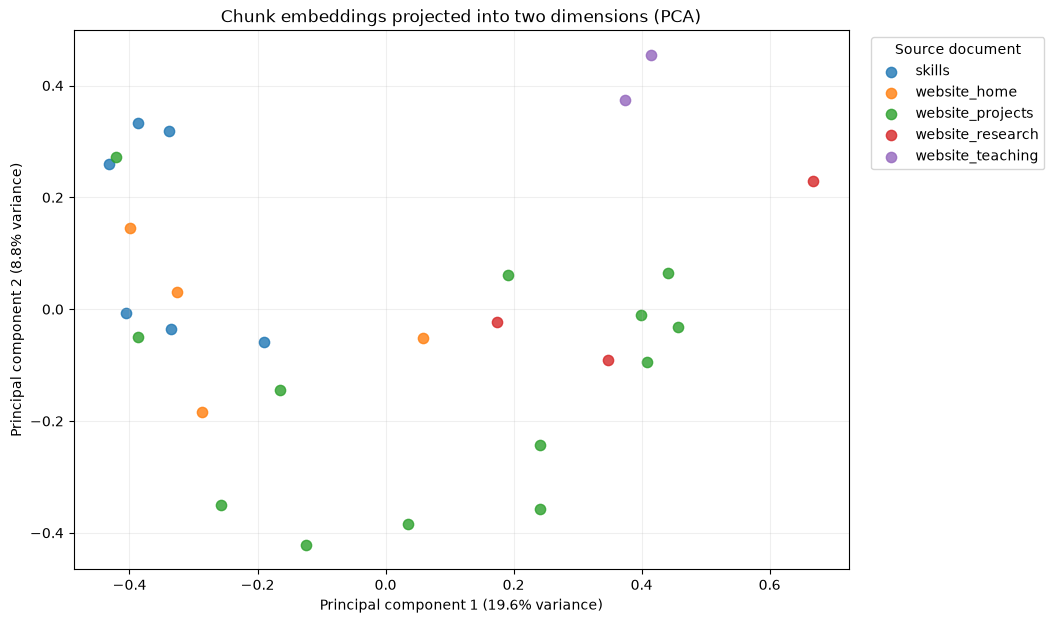

In [7]:
plot_table = pd.DataFrame(
    {
        "x": coordinates[:, 0],
        "y": coordinates[:, 1],
        "chunk_id": [chunk.chunk_id for chunk in chunks],
        "document_id": [chunk.document_id for chunk in chunks],
        "preview": [chunk.text.replace("\n", " ")[:90] for chunk in chunks],
    }
)

document_ids = sorted(plot_table["document_id"].unique())
colours = {
    document_id: plt.cm.tab10(index % 10)
    for index, document_id in enumerate(document_ids)
}

fig, ax = plt.subplots(figsize=(10, 7))
for document_id, group in plot_table.groupby("document_id"):
    ax.scatter(
        group["x"],
        group["y"],
        label=document_id,
        color=colours[document_id],
        alpha=0.8,
        s=55,
    )

ax.set_title("Chunk embeddings projected into two dimensions (PCA)")
ax.set_xlabel(f"Principal component 1 ({explained_ratio[0]:.1%} variance)")
ax.set_ylabel(f"Principal component 2 ({explained_ratio[1]:.1%} variance)")
ax.legend(title="Source document", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.2)
plt.show()

Points with the same colour came from the same document. Clusters can arise from shared topic, vocabulary, structure, or simply source-document style. Do not expect clean document-level clusters: a good corpus can contain semantically related chunks from different sources.

## 3. Place a query in the same view

The query is embedded with the same model and projected using the corpus PCA components. The highlighted chunks are the semantic retriever's nearest neighbours.

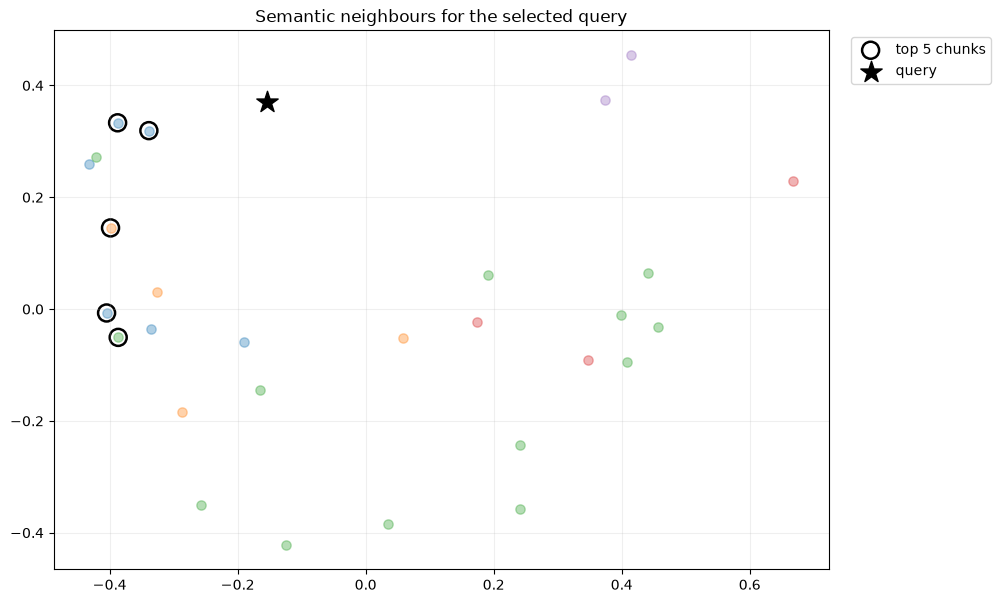

,rank,chunk_id,document_id,cosine_similarity,preview
0,1,skills_chunk_004,skills,0.521913,Risk \* Agriculture \* SmartFarm \* Tourism \*...
1,2,skills_chunk_000,skills,0.513824,# Marcelo Lares — Skills Review and Retrieval ...
2,3,website_home_chunk_000,website_home,0.395883,Applied AI technical leadership · data science...
3,4,skills_chunk_001,skills,0.346436,Recommendation Systems \* Recommender Systems ...
4,5,website_projects_chunk_000,website_projects,0.280288,Selected projects # Applied AI work from techn...


In [8]:
query = "What experience does Marcelo have with recommendation systems?"
TOP_K = 5

query_embedding = np.asarray(embedder.encode([query], normalize_embeddings=True)[0])
query_coordinate = (query_embedding - embedding_mean) @ components.T
similarity_scores = embeddings @ query_embedding
top_indices = np.argsort(similarity_scores)[::-1][:TOP_K]

fig, ax = plt.subplots(figsize=(10, 7))
for document_id, group in plot_table.groupby("document_id"):
    ax.scatter(group["x"], group["y"], color=colours[document_id], alpha=0.35, s=45)

ax.scatter(
    plot_table.iloc[top_indices]["x"],
    plot_table.iloc[top_indices]["y"],
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    s=150,
    label=f"top {TOP_K} chunks",
)
ax.scatter(
    [query_coordinate[0]],
    [query_coordinate[1]],
    marker="*",
    color="black",
    s=260,
    label="query",
)
ax.set_title("Semantic neighbours for the selected query")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.2)
plt.show()

pd.DataFrame(
    {
        "rank": range(1, TOP_K + 1),
        "chunk_id": [chunks[index].chunk_id for index in top_indices],
        "document_id": [chunks[index].document_id for index in top_indices],
        "cosine_similarity": similarity_scores[top_indices],
        "preview": [
            chunks[index].text.replace("\n", " ")[:250] for index in top_indices
        ],
    }
)

## 4. Inspect the nearest neighbours of a chunk

This is useful for detecting duplicate material, surprising semantic associations, or chunks that are too broad. Cosine similarity is not a truth score: read the text before deciding whether two chunks should be considered related evidence.

In [9]:
chunk_id = chunks[0].chunk_id
neighbour_count = 5

selected_index = next(
    index for index, chunk in enumerate(chunks) if chunk.chunk_id == chunk_id
)
selected_scores = embeddings @ embeddings[selected_index]
neighbour_indices = [
    index for index in np.argsort(selected_scores)[::-1] if index != selected_index
][:neighbour_count]

print(f"Selected chunk: {chunk_id}")
print(chunks[selected_index].text[:700])

pd.DataFrame(
    {
        "rank": range(1, len(neighbour_indices) + 1),
        "chunk_id": [chunks[index].chunk_id for index in neighbour_indices],
        "document_id": [chunks[index].document_id for index in neighbour_indices],
        "cosine_similarity": selected_scores[neighbour_indices],
        "preview": [
            chunks[index].text.replace("\n", " ")[:250] for index in neighbour_indices
        ],
    }
)

Selected chunk: skills_chunk_000
# Marcelo Lares — Skills Review and Retrieval Keywords ## Profile summary Marcelo Lares is a \*\*Lead Data Scientist / Applied AI / Machine Learning Engineering\*\* professional with a PhD in Astronomy and experience across scientific research, university teaching, technical leadership, consulting, and production machine learning. His strongest differentiator is combining \*\*statistical rigor, experimentation, reproducibility, and business-oriented ML delivery\*\*. His experience spans end-to-end work: problem framing, data analysis, feature engineering, model development, offline evaluation, A/B testing, deployment support, rollout, monitoring, documentation, and communication with technic


,rank,chunk_id,document_id,cosine_similarity,preview
0,1,skills_chunk_004,skills,0.696235,Risk \* Agriculture \* SmartFarm \* Tourism \*...
1,2,website_home_chunk_000,website_home,0.571725,Applied AI technical leadership · data science...
2,3,website_projects_chunk_012,website_projects,0.563601,Technical enablement ### University Data Scien...
3,4,website_projects_chunk_000,website_projects,0.540810,Selected projects # Applied AI work from techn...
4,5,website_home_chunk_001,website_home,0.511283,"tracked delivery, and aligned AI work with cli..."


## Questions to explore

1. Change `query` to a paraphrase with little word overlap. Compare these neighbours with BM25 in notebook 02.
2. Which chunks sit near material from another document? Is that a meaningful cross-source connection?
3. Do unusually broad chunks appear close to many unrelated topics? That may indicate a chunking problem.
4. Remember that PCA may hide structure. A retrieval decision should be justified by your benchmark and evidence review, not by the plot alone.